# Notebook 1 — Exploração de Dados e Detecção de Drift com Evidently AI

## Aula 8: Integração e Revisão (Ferramentas e Validação)

### Objetivos

1. Carregar e explorar o dataset sintético de **transações de pagamento** (10.000 registros).
2. Analisar distribuições de features entre períodos de **referência** (baseline) e **produção** (com drift).
3. Utilizar **Evidently AI** para gerar relatórios automatizados de data drift.
4. Calcular métricas de drift manualmente (KS, Wasserstein, Jensen-Shannon) e comparar com Evidently.
5. Identificar quais features apresentam **covariate drift**, **prior drift** e **concept drift**.

### Conexão com o Documento 04

> *"Vamos amarrar todos os principais conceitos de detecção de data drift apresentados ao longo do curso,*
> *conectando teoria e prática em um panorama unificado."*
> — DOCUMENTO_AULA_8.md, seção 'O Que Vem Por Aí'

### Vídeos Relacionados

- **Vídeo 8.1**: Recap dos conceitos (tipos de drift, detecção, mitigação).
- **Vídeo 8.2**: Ecossistema de ferramentas — Evidently AI, NannyML, Great Expectations.

In [1]:
# Imports
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import ks_2samp

# Adicionar diretório pai ao path para importar src/
sys.path.insert(0, str(Path.cwd().parent))

from src.data_preprocessing import (
    CATEGORICAL_FEATURES,
    NUMERIC_FEATURES,
    TARGET_COL,
    DataPreprocessor,
)
from src.evaluation import calculate_drift_metrics, calculate_all_features_drift

# Configurações de visualização
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12
sns.set_style("whitegrid")

%matplotlib inline

## 1. Carregamento dos Dados

O dataset simula transações de uma **plataforma de pagamentos global**, conforme o caso de negócio
descrito no Documento 04. Contém **10.000 transações** divididas em dois períodos:

| Período | Registros | % Fraude | Comportamento |
|---------|-----------|----------|---------------|
| Referência | 5.000 | ~5% | Baseline (distribuição estável) |
| Produção | 5.000 | ~8% | Com drift simulado |

Conforme o Documento 04 (seção 'Saiba Mais'):
> *"Dizemos que há drift no intervalo [t, t+Δ] se P_t(X, Y) ≠ P_{t+Δ}(X, Y)."*

In [2]:
# Carregar dataset
preprocessor = DataPreprocessor()

try:
    df = preprocessor.load_data("../data/raw/dataset.csv")
except FileNotFoundError:
    print("Dataset não encontrado. Execute primeiro:")
    print("  python scripts/generate_dataset.py")
    raise

print(f"Shape: {df.shape}")
print(f"Colunas: {list(df.columns)}")
print(f"\nDistribuição por período:")
print(df["periodo"].value_counts())

Shape: (10000, 17)
Colunas: ['transaction_id', 'timestamp', 'valor_transacao', 'tempo_conta_cliente', 'num_transacoes_24h', 'valor_medio_historico', 'distancia_localizacao', 'hora_transacao', 'tipo_cartao', 'canal_transacao', 'pais_origem', 'score_risco_dispositivo', 'tentativas_senha', 'is_weekend', 'razao_valor_medio', 'fraude', 'periodo']

Distribuição por período:
periodo
referencia    5000
producao      5000
Name: count, dtype: int64


## 2. Separação por Período: Referência vs Produção

Conforme o Documento 04, a detecção de drift compara **P_ref(X)** (dados de referência)
com **P_prod(X)** (dados de produção). Vamos separar os dados e analisar estatísticas descritivas.

In [3]:
# Separar dados por período
df_ref = df[df["periodo"] == "referencia"].copy()
df_prod = df[df["periodo"] == "producao"].copy()

print(f"Referência: {len(df_ref)} registros | Fraude: {df_ref['fraude'].mean():.2%}")
print(f"Produção:   {len(df_prod)} registros | Fraude: {df_prod['fraude'].mean():.2%}")

print("\n--- Estatísticas Descritivas: Referência ---")
display(df_ref[NUMERIC_FEATURES].describe().round(2))

print("\n--- Estatísticas Descritivas: Produção ---")
display(df_prod[NUMERIC_FEATURES].describe().round(2))

Referência: 5000 registros | Fraude: 5.00%
Produção:   5000 registros | Fraude: 8.00%

--- Estatísticas Descritivas: Referência ---


,valor_transacao,tempo_conta_cliente,num_transacoes_24h,valor_medio_historico,distancia_localizacao,hora_transacao,score_risco_dispositivo,tentativas_senha,is_weekend,razao_valor_medio
count,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00
mean,148.89,173.95,3.02,91.23,15.09,12.61,0.20,0.42,0.28,3.10
std,201.37,170.77,1.75,85.83,15.14,4.91,0.12,0.72,0.45,5.94
min,3.52,1.00,0.00,4.21,0.00,0.00,0.00,0.00,0.00,0.01
25%,46.62,52.00,2.00,38.06,4.33,9.00,0.11,0.00,0.00,0.58
50%,91.24,121.00,3.00,66.66,10.34,12.00,0.18,0.00,0.00,1.37
75%,175.21,241.00,4.00,114.47,21.14,16.00,0.27,1.00,1.00,3.29
max,4565.29,1444.00,11.00,1278.32,136.80,23.00,0.74,3.00,1.00,119.71



--- Estatísticas Descritivas: Produção ---


,valor_transacao,tempo_conta_cliente,num_transacoes_24h,valor_medio_historico,distancia_localizacao,hora_transacao,score_risco_dispositivo,tentativas_senha,is_weekend,razao_valor_medio
count,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00
mean,302.50,116.99,4.03,137.59,30.40,11.97,0.29,0.63,0.28,4.93
std,476.76,116.28,2.00,152.03,29.87,5.98,0.15,0.91,0.45,12.46
min,1.55,1.00,0.00,4.84,0.00,0.00,0.00,0.00,0.00,0.01
25%,67.97,33.00,3.00,49.64,8.59,8.00,0.18,0.00,0.00,0.62
50%,153.77,83.00,4.00,90.55,21.09,12.00,0.28,0.00,0.00,1.66
75%,338.96,161.00,5.00,168.64,42.62,17.00,0.39,1.00,1.00,4.64
max,10784.82,885.00,15.00,2963.19,221.87,23.00,0.81,3.00,1.00,339.94


## 3. Análise Visual de Drift por Feature

Conforme discutido no Documento 04 (seção 'Detecção Estatística de Data Drift'),
visualizar as distribuições lado a lado é o primeiro passo para identificar **covariate drift**.

> *"O Evidently destaca visualmente as diferenças — como histogramas comparativos,*
> *testes com p-values e indicações claras de quais colunas derivam do drift."*

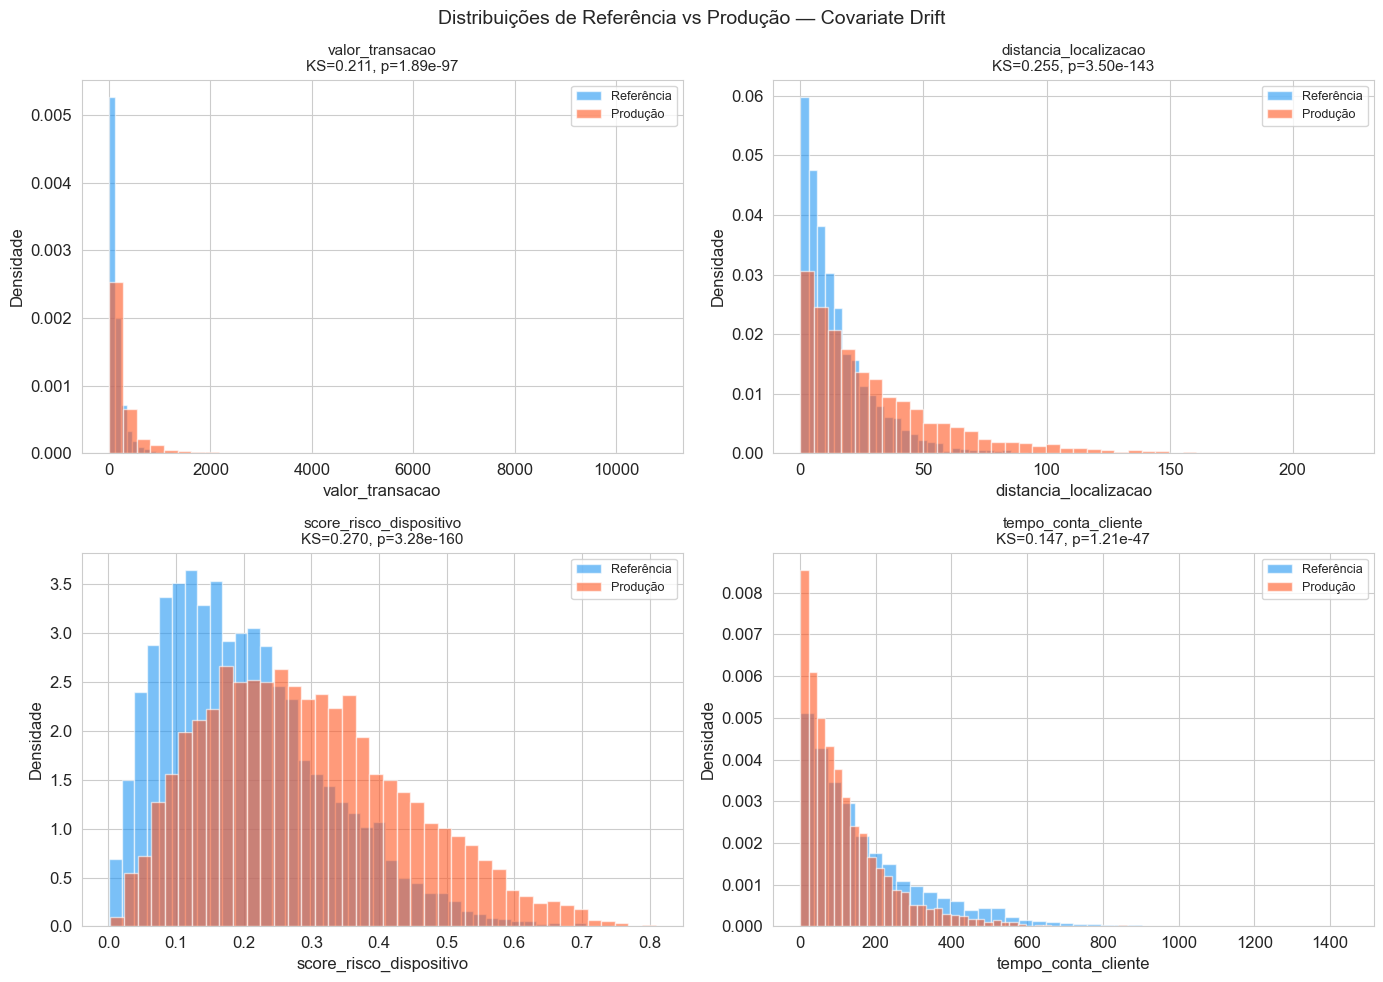

In [4]:
# Visualizar distribuições das 4 features mais relevantes
key_features = ["valor_transacao", "distancia_localizacao",
                "score_risco_dispositivo", "tempo_conta_cliente"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, feat in zip(axes.ravel(), key_features):
    ax.hist(df_ref[feat], bins=40, alpha=0.6, label="Referência", color="#2196F3", density=True)
    ax.hist(df_prod[feat], bins=40, alpha=0.6, label="Produção", color="#FF5722", density=True)
    
    # Calcular KS para anotação
    ks_stat, ks_p = ks_2samp(df_ref[feat], df_prod[feat])
    ax.set_title(f"{feat}\nKS={ks_stat:.3f}, p={ks_p:.2e}", fontsize=11)
    ax.set_xlabel(feat)
    ax.set_ylabel("Densidade")
    ax.legend(fontsize=9)

plt.suptitle("Distribuições de Referência vs Produção — Covariate Drift", fontsize=14)
plt.tight_layout()
plt.savefig("../outputs/figures/01_distribuicoes_drift.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Análise de Prior Drift (Label Drift)

Conforme o Documento 04:
> *"Prior drift (label drift): Mudanças na distribuição das classes P_t(Y) ≠ P_{t+Δ}(Y).*
> *Exemplo: na detecção de fraudes, a proporção de transações fraudulentas cai de 5% para 1%."*

No nosso dataset simulado, a taxa de fraude **aumenta** de ~5% para ~8%.

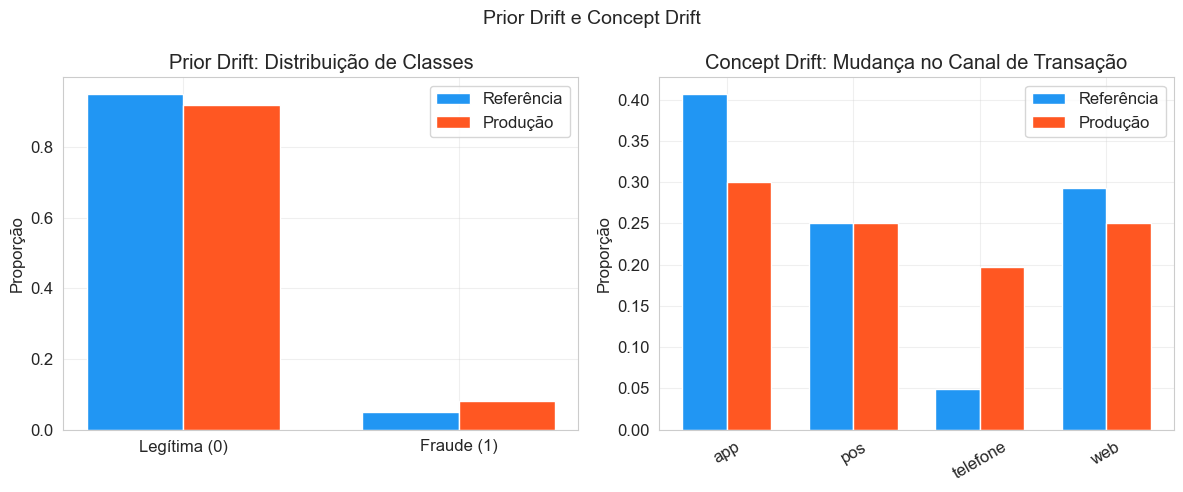

In [5]:
# Análise de Prior Drift
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Distribuição de fraude por período
ref_fraud_rate = df_ref["fraude"].value_counts(normalize=True)
prod_fraud_rate = df_prod["fraude"].value_counts(normalize=True)

labels = ["Legítima (0)", "Fraude (1)"]
x = np.arange(len(labels))
width = 0.35

axes[0].bar(x - width/2, [ref_fraud_rate.get(0, 0), ref_fraud_rate.get(1, 0)],
            width, label="Referência", color="#2196F3")
axes[0].bar(x + width/2, [prod_fraud_rate.get(0, 0), prod_fraud_rate.get(1, 0)],
            width, label="Produção", color="#FF5722")
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_ylabel("Proporção")
axes[0].set_title("Prior Drift: Distribuição de Classes")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Distribuição de canais (concept drift)
ref_canal = df_ref["canal_transacao"].value_counts(normalize=True)
prod_canal = df_prod["canal_transacao"].value_counts(normalize=True)
canais = sorted(set(ref_canal.index) | set(prod_canal.index))

x2 = np.arange(len(canais))
axes[1].bar(x2 - width/2, [ref_canal.get(c, 0) for c in canais],
            width, label="Referência", color="#2196F3")
axes[1].bar(x2 + width/2, [prod_canal.get(c, 0) for c in canais],
            width, label="Produção", color="#FF5722")
axes[1].set_xticks(x2)
axes[1].set_xticklabels(canais, rotation=30)
axes[1].set_ylabel("Proporção")
axes[1].set_title("Concept Drift: Mudança no Canal de Transação")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("Prior Drift e Concept Drift", fontsize=14)
plt.tight_layout()
plt.savefig("../outputs/figures/01_prior_concept_drift.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Métricas de Drift Calculadas Manualmente

Antes de usar o Evidently, vamos calcular manualmente as métricas de drift implementadas
no módulo `evaluation.py`, que correspondem às fórmulas do Documento 04:

- **KS statistic**: $D_{n,m} = \sup_x |F_{\text{ref}}(x) - F_{\text{prod}}(x)|$
- **Wasserstein distance**: custo de transformar $P$ em $Q$
- **Jensen-Shannon divergence**: versão simétrica da KL divergence

In [6]:
# Calcular métricas de drift para todas as features numéricas
drift_results = calculate_all_features_drift(df_ref, df_prod, NUMERIC_FEATURES)

print("=" * 75)
print("RESUMO DE DRIFT POR FEATURE (cálculo manual — módulo evaluation.py)")
print("=" * 75)
display(drift_results.round(4))

# Features com drift detectado
drifted = drift_results[drift_results["ks_drift_detected"]]
print(f"\nFeatures com drift detectado (p < 0.05): {len(drifted)}/{len(drift_results)}")
print(f"Features: {list(drifted.index)}")

RESUMO DE DRIFT POR FEATURE (cálculo manual — módulo evaluation.py)


c:\Personal\Others\FIAP\POSTECH-DATA_DRIFT\9mlet-data-drift\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)


,ks_statistic,ks_pvalue,ks_drift_detected,wasserstein_distance,jensen_shannon_divergence
feature,,,,,
valor_transacao,0.2106,0.0,True,153.6170,0.0257
tempo_conta_cliente,0.1472,0.0,True,56.9566,0.0204
num_transacoes_24h,0.2164,0.0,True,1.0084,0.0352
valor_medio_historico,0.1574,0.0,True,46.3631,0.0186
distancia_localizacao,0.2550,0.0,True,15.3055,0.0553
hora_transacao,0.0968,0.0,True,0.9366,0.0197
score_risco_dispositivo,0.2696,0.0,True,0.0922,0.0577
tentativas_senha,0.0880,0.0,True,0.2080,0.0090
is_weekend,0.0012,1.0,False,0.0012,0.0000



Features com drift detectado (p < 0.05): 9/10
Features: ['valor_transacao', 'tempo_conta_cliente', 'num_transacoes_24h', 'valor_medio_historico', 'distancia_localizacao', 'hora_transacao', 'score_risco_dispositivo', 'tentativas_senha', 'razao_valor_medio']


## 6. Detecção de Drift com Evidently AI

Conforme o **Snippet 1** do Hands On do Documento 04:
> *"Utilizamos o preset DataDriftPreset() do Evidently, que aplica diversos testes e métricas*
> *(como testes de hipótese tipo KS e AD, e distâncias como Wasserstein ou Jensen-Shannon)*
> *em cada coluna dos dados."*

O Evidently automatiza o cálculo que fizemos manualmente acima, gerando relatórios visuais.

In [11]:
# Detecção de drift com Evidently AI
# Implementa Snippet 1 do Hands On do Documento 04
# OBS: Evidently >= 0.7 mudou a API. Imports e extração de resultados abaixo
# seguem a nova API (evidently.presets + snapshot.dict()).
try:
    from evidently import Report
    from evidently.presets import DataDriftPreset

    # Selecionar features relevantes (excluir IDs e metadados)
    feature_cols = NUMERIC_FEATURES + CATEGORICAL_FEATURES
    ref_for_evidently = df_ref[feature_cols].copy()
    prod_for_evidently = df_prod[feature_cols].copy()

    # Configurar e executar relatório — conforme Snippet 1 do Doc 04
    report = Report(metrics=[DataDriftPreset()])
    snapshot = report.run(reference_data=ref_for_evidently, current_data=prod_for_evidently)

    # Extrair resumo da nova estrutura de resultados (snapshot.dict())
    result = snapshot.dict()
    metrics = result["metrics"]

    # Métrica agregada: contagem/proporção de colunas com drift
    drift_count = next(
        (m for m in metrics if m["metric_name"].startswith("DriftedColumnsCount")),
        None,
    )
    # Métricas por coluna (ValueDrift) — uma por feature analisada
    value_drifts = [m for m in metrics if m["metric_name"].startswith("ValueDrift")]

    n_total = len(value_drifts)
    n_drifted = int(drift_count["value"]["count"]) if drift_count else "N/A"
    drift_share = drift_count["value"]["share"] if drift_count else 0.0
    dataset_drift = bool(drift_share >= 0.5)

    print(f"Evidently DataDriftPreset: {n_drifted} de {n_total} features com drift detectado.")
    print(f"Proporção de colunas com drift: {drift_share:.1%}")
    print(f"Dataset drift detected: {dataset_drift}")

    # Salvar relatório HTML
    snapshot.save_html("../outputs/figures/evidently_drift_report.html")
    print("\nRelatório HTML salvo em: outputs/figures/evidently_drift_report.html")

except ImportError:
    print("Evidently AI não instalado. Instale com: pip install evidently")
    print("Continuando com métricas manuais calculadas anteriormente.")


Evidently DataDriftPreset: 10 de 13 features com drift detectado.
Proporção de colunas com drift: 76.9%
Dataset drift detected: True

Relatório HTML salvo em: outputs/figures/evidently_drift_report.html


## 7. Visualização do Resumo de Drift

Vamos gerar uma visualização consolidada mostrando as métricas de drift por feature,
similar ao dashboard que ferramentas como Evidently e WhyLabs produzem.

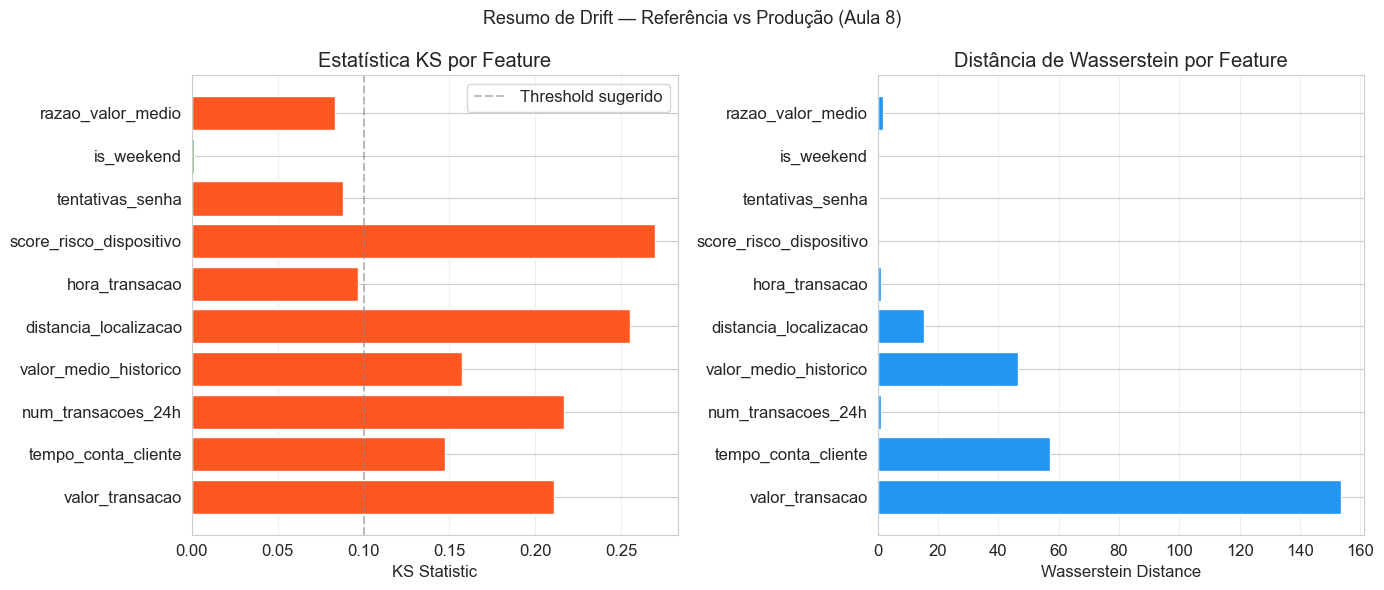

c:\Personal\Others\FIAP\POSTECH-DATA_DRIFT\9mlet-data-drift\08_integracao_e_revisao_ferramentas_e_validacao\src\evaluation.py:392: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data_for_box, x="Período", y="Valor", ax=axes[1], palette=["#2196F3", "#FF5722"])


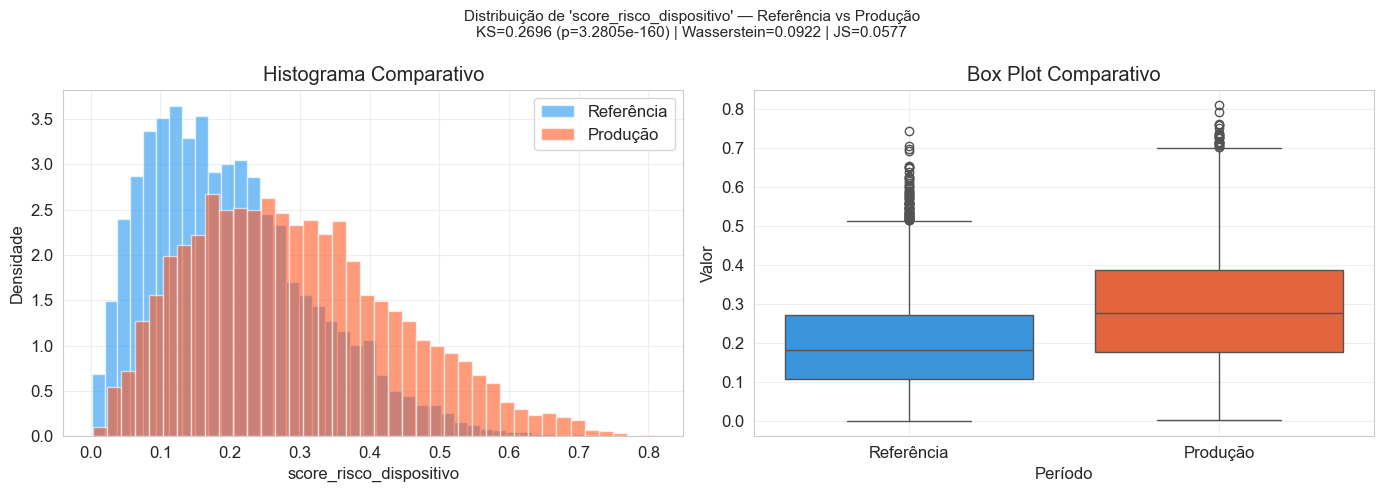

In [8]:
from src.evaluation import plot_drift_summary, plot_drift_comparison

# Resumo geral de drift
fig_summary = plot_drift_summary(
    drift_results,
    title="Resumo de Drift — Referência vs Produção (Aula 8)",
    save_path="../outputs/figures/01_drift_summary.png",
)
plt.show()

# Comparação detalhada para a feature com maior drift
top_drift_feat = drift_results["ks_statistic"].idxmax()
fig_detail = plot_drift_comparison(
    df_ref[top_drift_feat].values,
    df_prod[top_drift_feat].values,
    feature_name=top_drift_feat,
    save_path=f"../outputs/figures/01_drift_detail_{top_drift_feat}.png",
)
plt.show()

## 8. Correlação entre Features

Conforme o Documento 04 (seção sobre técnicas multivariadas e MMD):
> *"Existem métodos que consideram correlações entre variáveis — por exemplo,*
> *testes de dois conjuntos baseados em embeddings de alta dimensão."*

Vamos visualizar se a estrutura de correlação mudou entre referência e produção.

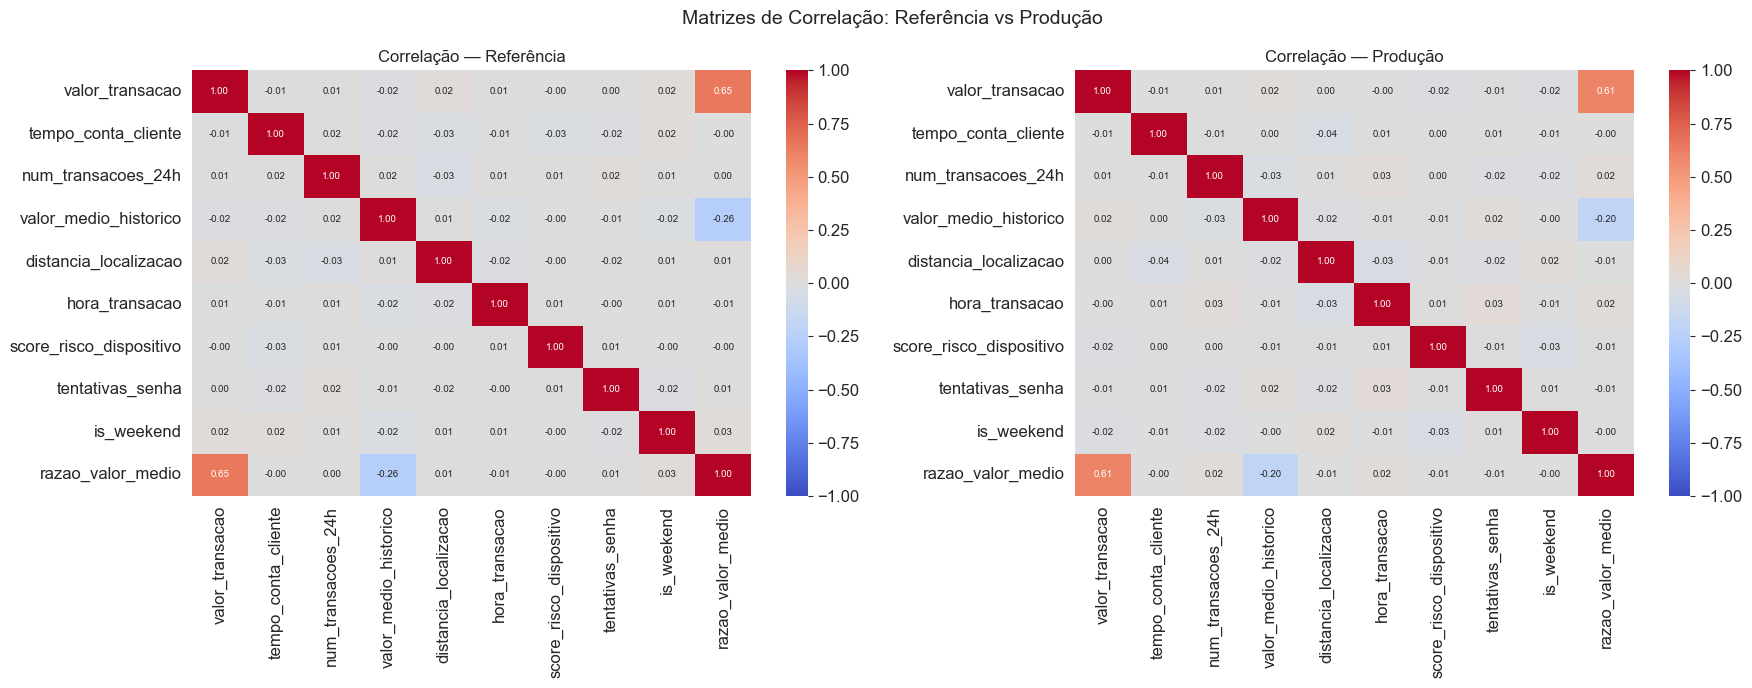

Top 5 pares de features com maior mudança na correlação:
  valor_medio_historico ↔ razao_valor_medio: Δ|r| = 0.0650
  valor_transacao ↔ razao_valor_medio: Δ|r| = 0.0463
  num_transacoes_24h ↔ valor_medio_historico: Δ|r| = 0.0447
  valor_transacao ↔ valor_medio_historico: Δ|r| = 0.0427
  num_transacoes_24h ↔ distancia_localizacao: Δ|r| = 0.0426


In [9]:
# Comparar matrizes de correlação
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

corr_ref = df_ref[NUMERIC_FEATURES].corr()
corr_prod = df_prod[NUMERIC_FEATURES].corr()

sns.heatmap(corr_ref, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            ax=axes[0], vmin=-1, vmax=1, annot_kws={"size": 7})
axes[0].set_title("Correlação — Referência", fontsize=12)

sns.heatmap(corr_prod, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            ax=axes[1], vmin=-1, vmax=1, annot_kws={"size": 7})
axes[1].set_title("Correlação — Produção", fontsize=12)

plt.suptitle("Matrizes de Correlação: Referência vs Produção", fontsize=14)
plt.tight_layout()
plt.savefig("../outputs/figures/01_correlation_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# Diferença nas correlações
corr_diff = (corr_prod - corr_ref).abs()
print("Top 5 pares de features com maior mudança na correlação:")
upper = corr_diff.where(np.triu(np.ones_like(corr_diff, dtype=bool), k=1))
pairs = upper.stack().nlargest(5)
for (f1, f2), val in pairs.items():
    print(f"  {f1} ↔ {f2}: Δ|r| = {val:.4f}")

## Resumo e Próximos Passos

### O que aprendemos neste notebook:

1. **EDA por período**: Visualizamos as diferenças entre dados de referência e produção.
2. **Covariate drift**: Features como `valor_transacao` e `distancia_localizacao` mudaram significativamente.
3. **Prior drift**: A taxa de fraude aumentou de ~5% para ~8%.
4. **Concept drift**: O canal `telefone` teve aumento expressivo na produção.
5. **Métricas manuais**: Calculamos KS, Wasserstein e Jensen-Shannon para cada feature.
6. **Evidently AI**: Automatiza a detecção e gera relatórios HTML interativos.

### Próximo notebook

No **Notebook 02 (Treinamento)**, vamos:
- Treinar o modelo de detecção de fraude (Random Forest) nos dados de referência.
- Avaliar performance nos dados de produção (com drift).
- Usar **NannyML CBPE** para estimar a queda de performance sem ground truth.

---
*Notebook conectado com: DOCUMENTO_AULA_8.md | Vídeos 8.1 e 8.2*